In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [8]:
pip install yellowbrick

Note: you may need to restart the kernel to use updated packages.


In [9]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns = data.feature_names)
df.iloc[:10,4] = np.nan
print(df.shape)
df.head()

(569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,NaN,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,NaN,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,NaN,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,NaN,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,NaN,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [10]:
from sklearn.pipeline import Pipeline

from feature_engine.imputation import MeanMedianImputer

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans


def PipelineCluster():
    pipeline_base = Pipeline([
        ("MeanMedianImputer", MeanMedianImputer(
            imputation_method = "median",
            variables = ["mean smoothness"]
        )),
        ("Scaler", StandardScaler()),
        ("PCA", PCA(n_components = 50, random_state = 0)),
        ("model", KMeans(n_clusters = 50, random_state = 0))
    ])
    return pipeline_base

PipelineCluster()

,steps,"[('MeanMedianImputer', ...), ('Scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,imputation_method,'median'
,variables,['mean smoothness']
,copy,True
,with_mean,True
,with_std,True
,n_components,50
,copy,True


In [11]:
pipeline_cluster =  PipelineCluster()
pipeline_pca  = Pipeline(pipeline_cluster.steps[:-2])
df_pca = pipeline_pca.fit_transform(df)

print(df_pca.shape, "\n", type(df_pca))

(569, 30) 
 <class 'numpy.ndarray'>


In [12]:
df_pca

array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]])

In [13]:
n_components = 30

pca = PCA(n_components = n_components).fit(df_pca)
x_pca = pca.transform(df_pca)

ComponentsList = ["Component " + str(number) for number in range(n_components)]
dfExplVarRatio = pd.DataFrame(
    data = np.round(100 * pca.explained_variance_ratio_, 3),
    index = ComponentsList,
    columns = ["Explained Variance Ratio (%)"]
)

PercentageofDataExplained = dfExplVarRatio["Explained Variance Ratio (%)"].sum()

print(f"* The {n_components} components explain {round(PercentageofDataExplained, 2)} % of the data \n")
print(dfExplVarRatio)

* The 30 components explain 100.0 % of the data 

              Explained Variance Ratio (%)
Component 0                         44.207
Component 1                         18.858
Component 2                          9.361
Component 3                          6.612
Component 4                          5.482
Component 5                          4.094
Component 6                          2.285
Component 7                          1.613
Component 8                          1.390
Component 9                          1.165
Component 10                         0.976
Component 11                         0.895
Component 12                         0.806
Component 13                         0.572
Component 14                         0.315
Component 15                         0.275
Component 16                         0.195
Component 17                         0.183
Component 18                         0.166
Component 19                         0.104
Component 20                         0.103
Comp

In [14]:
n_components = 7

pca = PCA(n_components = n_components).fit(df_pca)
x_pca = pca.transform(df_pca)

ComponentsList = ["Component " + str(number) for number in range(n_components)]
dfExplVarRatio = pd.DataFrame(
    data = np.round(100 * pca.explained_variance_ratio_, 3),
    index = ComponentsList,
    columns = ["Explained Variance Ratio (%)"]
)

PercentageofDataExplained = dfExplVarRatio["Explained Variance Ratio (%)"].sum()

print(f"* The {n_components} components explain {round(PercentageofDataExplained, 2)} % of the data \n")
print(dfExplVarRatio)

* The 7 components explain 90.9 % of the data 

             Explained Variance Ratio (%)
Component 0                        44.207
Component 1                        18.858
Component 2                         9.361
Component 3                         6.612
Component 4                         5.482
Component 5                         4.094
Component 6                         2.285


In [15]:
def PipelineCluster():
    pipeline_base = Pipeline([
        ("MeanMedianImputer", MeanMedianImputer(
            imputation_method = "median",
            variables = ["mean smoothness"])),

        ("Scaler", StandardScaler()),
        ("PCA", PCA(n_components = 7, random_state=0)),
        ("model", KMeans(n_clusters = 30, random_state=0))
        
    ])
    return pipeline_base

PipelineCluster()

,steps,"[('MeanMedianImputer', ...), ('Scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,imputation_method,'median'
,variables,['mean smoothness']
,copy,True
,with_mean,True
,with_std,True
,n_components,7
,copy,True


In [16]:
pipeline_cluster = PipelineCluster()
pipeline_analysis = Pipeline(pipeline_cluster.steps[:-1])
df_analysis = pipeline_analysis.fit_transform(df)

print(df_analysis.shape, "\n", type(df_analysis))

(569, 7) 
 <class 'numpy.ndarray'>


In [17]:
pipeline_cluster.steps

[('MeanMedianImputer', MeanMedianImputer(variables=['mean smoothness'])),
 ('Scaler', StandardScaler()),
 ('PCA', PCA(n_components=7, random_state=0)),
 ('model', KMeans(n_clusters=30, random_state=0))]

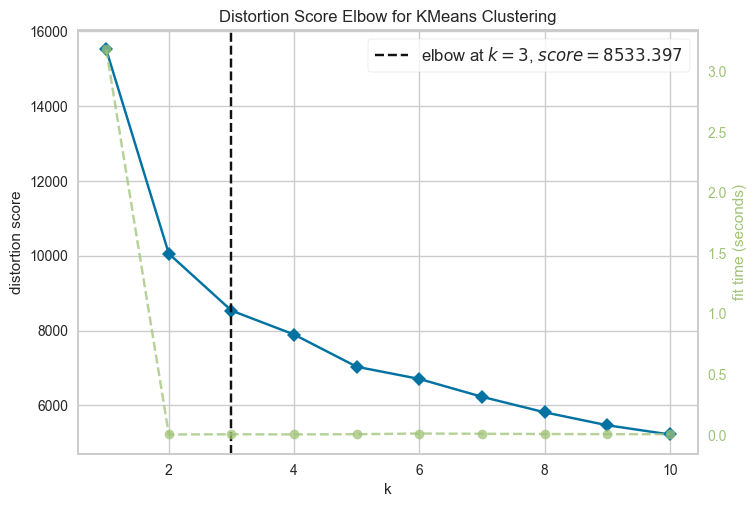

In [18]:
from yellowbrick.cluster import KElbowVisualizer

visualizer = KElbowVisualizer(KMeans(random_state=0), k=(1, 11))
visualizer.fit(df_analysis)
visualizer.show()
plt.show()

=== Average Silhoutte Score for different number of clusters ===


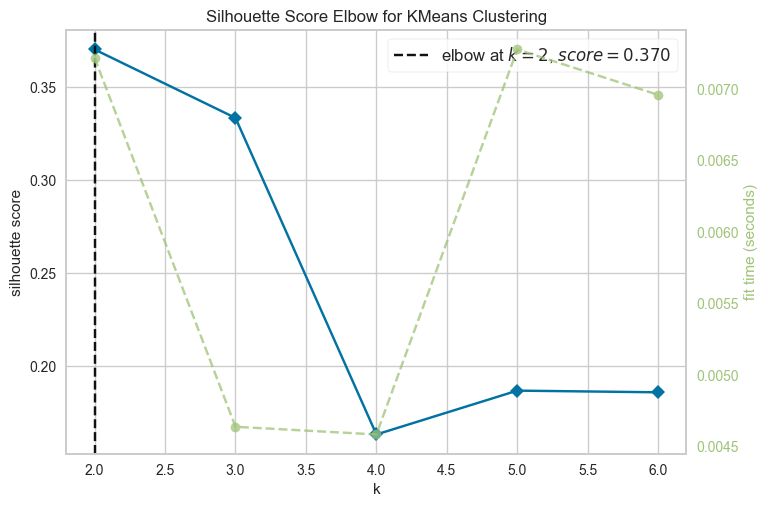



=== Silhoutte plot for 2 Clusters ===


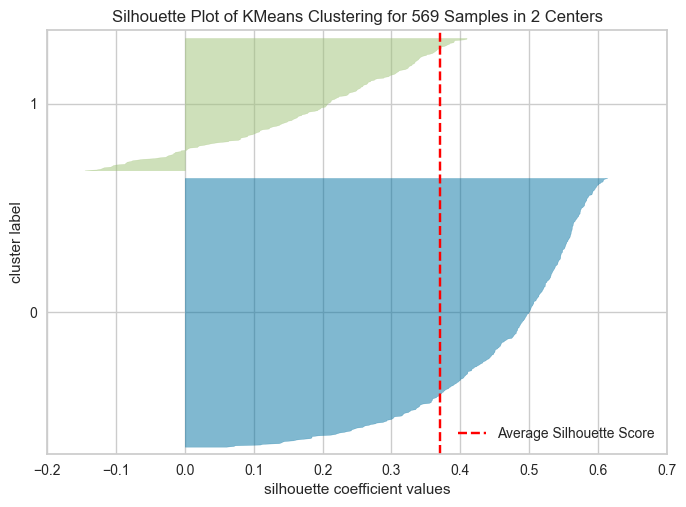



=== Silhoutte plot for 3 Clusters ===


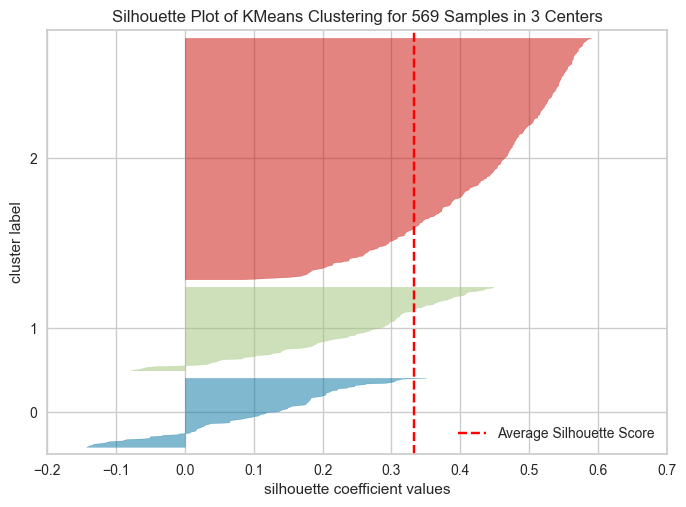



=== Silhoutte plot for 4 Clusters ===


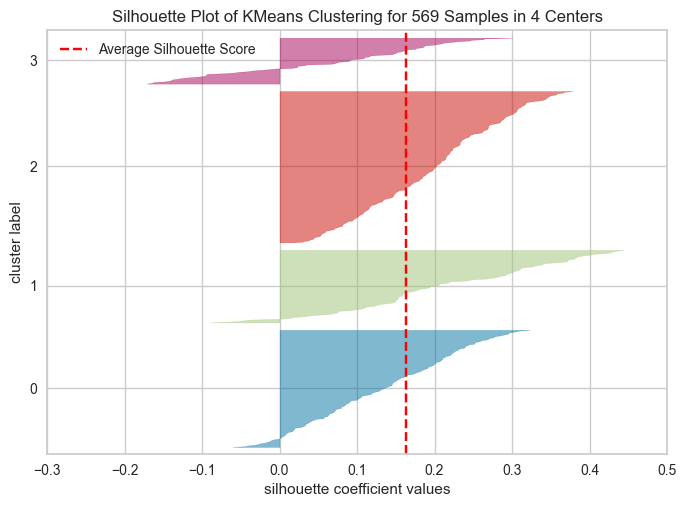



=== Silhoutte plot for 5 Clusters ===


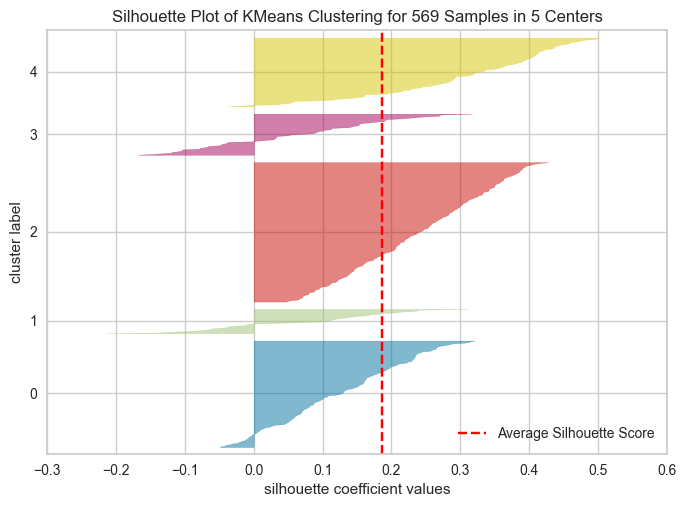



=== Silhoutte plot for 6 Clusters ===


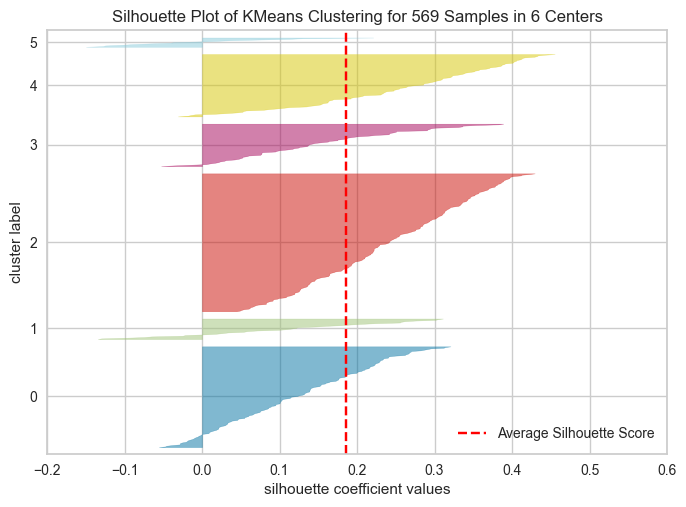



=== Silhoutte plot for 7 Clusters ===


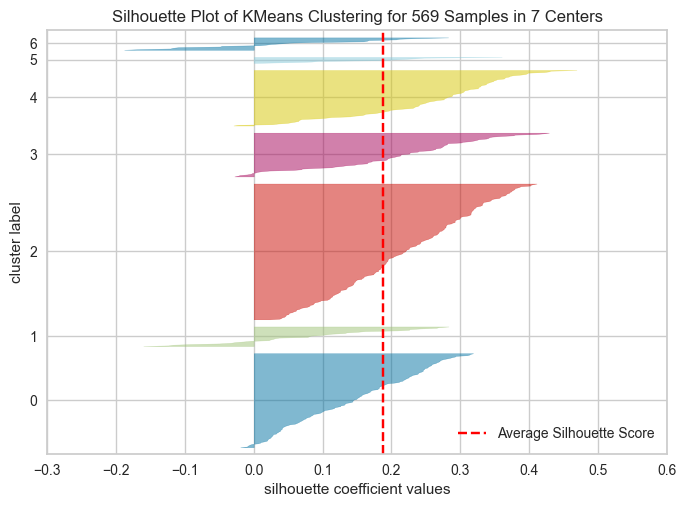



=== Silhoutte plot for 8 Clusters ===


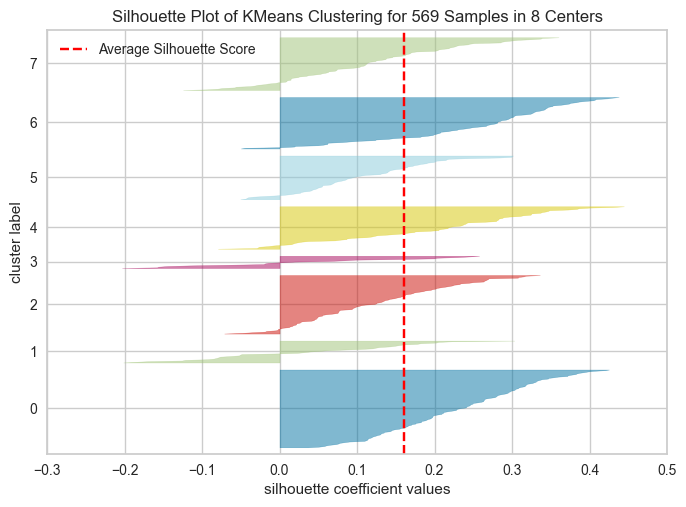



=== Silhoutte plot for 9 Clusters ===


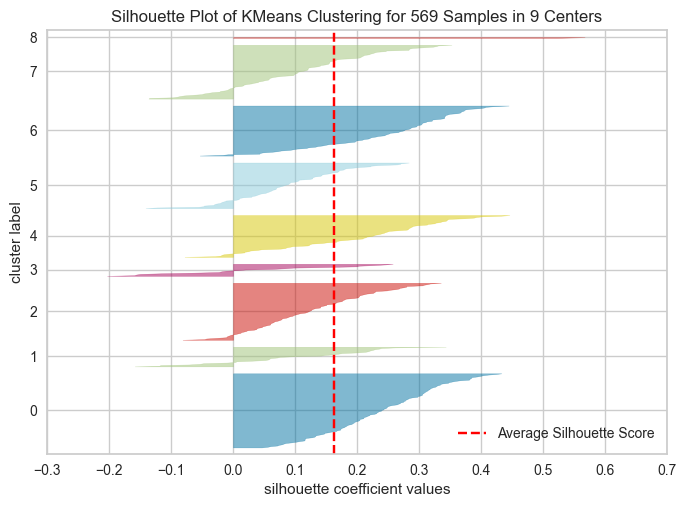



=== Silhoutte plot for 10 Clusters ===


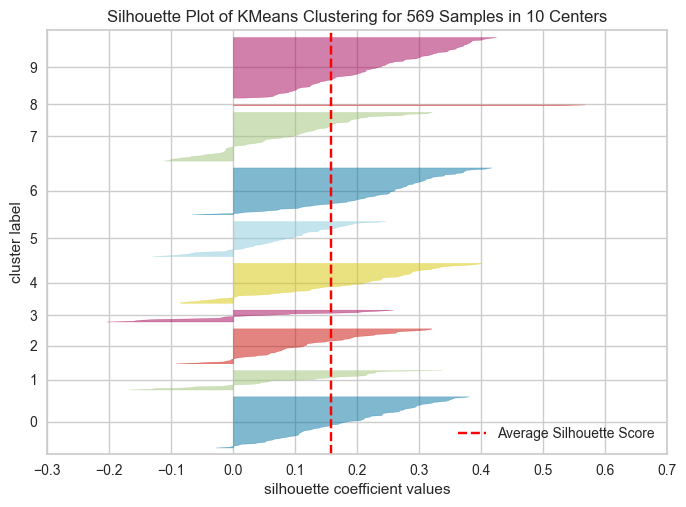

In [19]:
from yellowbrick.cluster import SilhouetteVisualizer

print("=== Average Silhoutte Score for different number of clusters ===")
visualizer = KElbowVisualizer(KMeans(random_state = 0), k = (2, 7), metric = "silhouette" )
visualizer.fit(df_analysis)
visualizer.show()
plt.show()
print("\n")

for n_clusters in np.arange(start = 2, stop = 11):

    print(f"=== Silhoutte plot for {n_clusters} Clusters ===")
    visualizer = SilhouetteVisualizer(estimator = KMeans(n_clusters = n_clusters, random_state = 0), colors = "yellowbrick")
    visualizer.fit(df_analysis)
    visualizer.show()
    plt.show()
    print("\n")

In [20]:
def PipelineCluster():
    pipeline_base = Pipeline([
        ("MeanMedianImputer", MeanMedianImputer(imputation_method = "median", variables= ["mean smoothness"])),

        ("scaler", StandardScaler()),
        ("PCA", PCA(n_components = 7, random_state = 0)),
        ("model", KMeans(n_clusters = 3, random_state = 0))   

    ])
    return pipeline_base

PipelineCluster()

,steps,"[('MeanMedianImputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,imputation_method,'median'
,variables,['mean smoothness']
,copy,True
,with_mean,True
,with_std,True
,n_components,7
,copy,True


In [21]:
X = df.copy()
print(X.shape)
X.head(3)

(569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,NaN,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,NaN,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,NaN,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [22]:
pipeline_cluster = PipelineCluster()
pipeline_cluster.fit(X)

,steps,"[('MeanMedianImputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,imputation_method,'median'
,variables,['mean smoothness']
,copy,True
,with_mean,True
,with_std,True
,n_components,7
,copy,True


In [23]:
X["Clusters"] = pipeline_cluster["model"].labels_
print(X.shape)
X.head(3)

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Clusters
0,17.99,10.38,122.8,1001.0,NaN,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.9,1326.0,NaN,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.0,1203.0,NaN,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1


* Clusters frequency 
           proportion
Clusters            
2               0.61
1               0.21
0               0.18




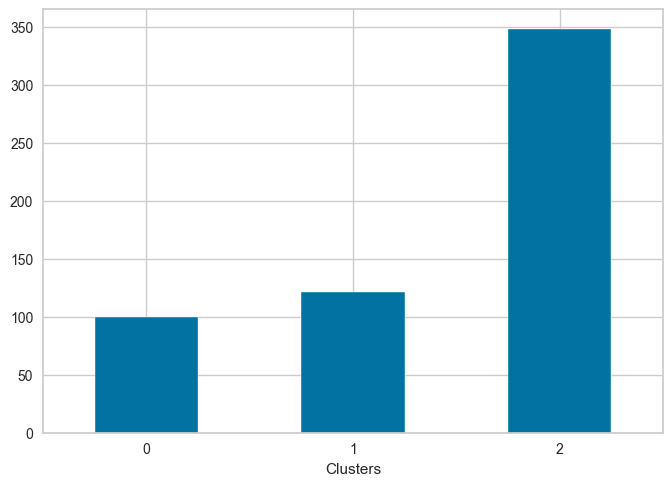

In [24]:
print(f"* Clusters frequency \n {X["Clusters"].value_counts(normalize = True).to_frame().round(2)}\n\n")
X["Clusters"].value_counts().sort_values().plot(kind = "bar")
plt.xticks(rotation = 0)
plt.show()

In [25]:
df_clf = X.copy()
print(df_clf.shape)
df_clf.head(3)

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Clusters
0,17.99,10.38,122.8,1001.0,NaN,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.9,1326.0,NaN,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.0,1203.0,NaN,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1


In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df_clf.drop(["Clusters"], axis = 1),
    df_clf["Clusters"],
    test_size = 0.2,
    random_state = 0,
)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(455, 30) (455,) (114, 30) (114,)


In [27]:
from sklearn.feature_selection import SelectFromModel

from sklearn.ensemble import GradientBoostingClassifier

def PipelineClf2ExplainClusters():

    pipeline_base = Pipeline([
        ("MeanMedianImputer", MeanMedianImputer(imputation_method = "median", variables = ["mean smoothness"])),
        ("Scaler", StandardScaler()),
        ("feat_selection", SelectFromModel(GradientBoostingClassifier(random_state=0))),
        ("model", GradientBoostingClassifier(random_state=0))
    ])
    return pipeline_base

PipelineClf2ExplainClusters()

,steps,"[('MeanMedianImputer', ...), ('Scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,imputation_method,'median'
,variables,['mean smoothness']
,copy,True
,with_mean,True
,with_std,True
,estimator,GradientBoost...andom_state=0)
,threshold,None


In [28]:
pipeline_clf_clusters = PipelineClf2ExplainClusters()
pipeline_clf_clusters.fit(X_train, y_train)

,steps,"[('MeanMedianImputer', ...), ('Scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,imputation_method,'median'
,variables,['mean smoothness']
,copy,True
,with_mean,True
,with_std,True
,estimator,GradientBoost...andom_state=0)
,threshold,None


In [29]:
pipeline_clf_clusters['model'].feature_importances_

array([0.39764015, 0.07976354, 0.32791016, 0.19468616])

In [30]:
from sklearn.metrics import classification_report
print(classification_report(y_train, pipeline_clf_clusters.predict(X_train)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        76
           1       1.00      1.00      1.00        95
           2       1.00      1.00      1.00       284

    accuracy                           1.00       455
   macro avg       1.00      1.00      1.00       455
weighted avg       1.00      1.00      1.00       455



In [31]:
print(classification_report(y_test, pipeline_clf_clusters.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        24
           1       0.96      1.00      0.98        26
           2       0.98      1.00      0.99        64

    accuracy                           0.98       114
   macro avg       0.98      0.97      0.98       114
weighted avg       0.98      0.98      0.98       114



In [32]:
pipeline_clf_clusters

,steps,"[('MeanMedianImputer', ...), ('Scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,imputation_method,'median'
,variables,['mean smoothness']
,copy,True
,with_mean,True
,with_std,True
,estimator,GradientBoost...andom_state=0)
,threshold,None


* These are the 4 most important features in descending order.The model was trained on them: 
['mean concavity', 'worst perimeter', 'worst fractal dimension', 'area error'] 



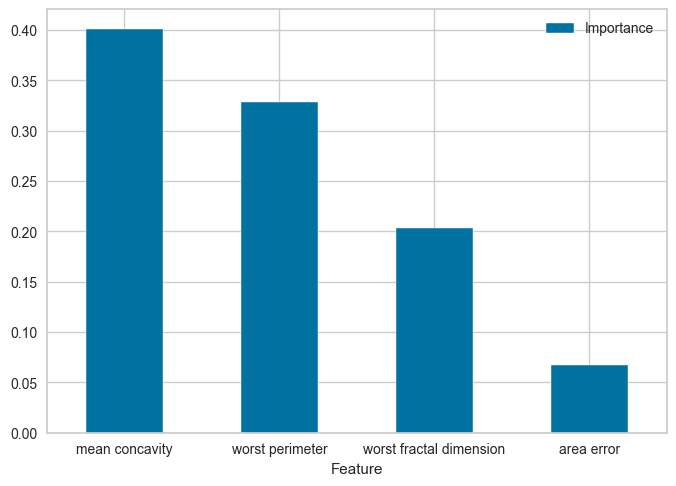

In [ ]:
data_cleaning_feat_eng_steps = 1
columns_after_data_cleaning_feat_eng = (Pipeline(pipeline_clf_clusters.steps[:data_cleaning_feat_eng_steps])
                            .transform(X_train)
                            .columns)

best_features = columns_after_data_cleaning_feat_eng[pipeline_clf_clusters["feat_selection"].get_support()].tolist()

df_feature_importance = pd.DataFrame(data = {
    "Feature": columns_after_data_cleaning_feat_eng[pipeline_clf_clusters["feat_selection"].get_support()],
    "Importance": pipeline_clf_clusters["model"].feature_importances_}).sort_values(by = "Importance", ascending = False)

best_features = df_feature_importance["Feature"].to_list()

print(f"* These are the {len(best_features)} most important features in descending order." f"The model was trained on them: \n{best_features} \n")
df_feature_importance.plot(kind = "bar", x= "Feature", y= "Importance")
plt.xticks(rotation = 0)
plt.show()


In [ ]:
def DescriptionAllClusters(df, decimal_points = 3):
    cluster_descriptions = []
    #DescriptionAllClusters = pd.DataFrame(columns=df.drop(["Clusters"], axis = 1).columns)

    for cluster in df.sort_values(by = "Clusters")["Clusters"].unique():

        EDA_ClusterSubset = df.query(f"Clusters == {cluster}").drop(["Clusters"], axis = 1)
        ClusterDescription = Clusters_IndividualDescription(EDA_ClusterSubset, cluster, decimal_points)
        cluster_descriptions.append(ClusterDescription)

    #DescriptionAllClusters = DescriptionAllClusters.set_index(["Cluster"])
    DescriptionAllClusters = pd.concat(cluster_descriptions, axis = 0)
    return DescriptionAllClusters

def Clusters_IndividualDescription(EDA_Cluster, cluster, decimal_points):
    ClustersDescription = pd.DataFrame(columns = EDA_Cluster.columns)

    for col in EDA_Cluster.columns:
        try:
            if EDA_Cluster[col].dtype == "object":
                top_frequencies = EDA_Cluster.dropna(subset = [col])[[col]].value_counts(normalize = True).nlargest(n = 3)
                Description = " "

                for x in range(len(top_frequencies)):
                    freq = top_frequencies.iloc[x]
                    category = top_frequencies.index[x][0]
                    CategoryPercentage = int(round(freq * 100, 0))
                    statement = f"'{category}' : {CategoryPercentage} %"
                    Description = Description + statement

                ClustersDescription.at[0, col] = Description[:-2]

            elif EDA_Cluster[col].dtypes in ["float", "int"]:
                DescStats = EDA_Cluster.dropna(subset=[col])[[col]].describe()
                Q1 = round(DescStats.iloc[4, 0], decimal_points)
                Q3 = round(DescStats.iloc[6,0], decimal_points)
                Description = f"{Q1}  -- {Q3}"
                ClustersDescription.at[0, col] = Description

        except Exception as e:
            ClustersDescription.at[0, col] = "Not available"
            print(f"Error Exception: {e} - cluster {cluster}, variable {col}")

    ClustersDescription["Cluster"] = str(cluster)
    return ClustersDescription    

In [ ]:
import plotly.express as px

def cluster_distribution_per_variable(df, target):
    df_bar_plot = df.value_counts(["Clusters", target]).reset_index()
    df_bar_plot.columns = ["Clusters", target, "Count"]
    df_bar_plot[target] = df_bar_plot[target].astype("object")

    print (f"Clusters distribution across {target} levels")
    fig = px.bar(df_bar_plot, x = "Clusters", y = "Count", color = target, width = 800, height = 400)
    fig.update_layout(xaxis = dict(tickmode = "array", tickvals = df["Clusters"].nunique()))
    fig.show()

    df_relative = (df
                   .groupby(["Clusters", target])
                   .size()
                   .groupby(level = 0)
                   .apply(lambda x: 100 * x/ x.sum())
                   .reset_index()
                   .sort_values(by = ["Clusters"]))

    df_relative.columns = ["Clusters", target, "Relative Percentage (%)"]

    print(f"Relative Percentage (%) of {target} in each cluster")
    fig = px.line(df_relative, x="Clusters", y="Relative Percentage (%)", color = target, width = 800, height = 500)
    fig.update_layout(xaxis = dict(tickmode = "array", tickvals = df["Clusters"].unique()))
    fig.update_traces(mode = "markers + lines")
    fig.show()

In [ ]:
df_cluster_profile = df_clf.copy()
df_cluster_profile = df_cluster_profile.filter(items = best_features + ["Clusters"], axis = 1)
print(df_cluster_profile.shape)
df_cluster_profile.head(3)

(569, 5)


,mean concavity,worst perimeter,worst fractal dimension,area error,Clusters
0,0.3001,184.6,0.11890,153.40,2
1,0.0869,158.8,0.08902,74.08,2
2,0.1974,152.5,0.08758,94.03,2


In [ ]:
df_diagnostic = pd.DataFrame(data.target, columns = ["diagnostic"])
df_diagnostic["diagnostic"] = df_diagnostic["diagnostic"].astype("object")
df_diagnostic.head(3)

,diagnostic
0,0
1,0
2,0


In [ ]:
con_df = pd.concat([df_cluster_profile, df_diagnostic], axis = 1).head(5)
con_df

,mean concavity,worst perimeter,worst fractal dimension,area error,Clusters,diagnostic
0,0.3001,184.60,0.11890,153.40,2,0
1,0.0869,158.80,0.08902,74.08,2,0
2,0.1974,152.50,0.08758,94.03,2,0
3,0.2414,98.87,0.17300,27.23,0,0
4,0.1980,152.20,0.07678,94.44,2,0


In [ ]:
DescriptionAllClusters(con_df, decimal_points = 2)

,mean concavity,worst perimeter,worst fractal dimension,area error,diagnostic,Cluster
0,0.24 -- 0.24,98.87 -- 98.87,0.17 -- 0.17,27.23 -- 27.23,'0' : 100,0
0,0.17 -- 0.22,152.43 -- 165.25,0.08 -- 0.1,89.04 -- 109.18,'0' : 100,2


In [ ]:
pd.set_option("display.max_colwidth", None)
Clusters_profile = DescriptionAllClusters(df = pd.concat([df_cluster_profile, df_diagnostic], axis = 1),
                                          decimal_points = 2)
Clusters_profile  

,mean concavity,worst perimeter,worst fractal dimension,area error,diagnostic,Cluster
0,0.1 -- 0.18,91.84 -- 120.1,0.1 -- 0.12,21.0 -- 40.54,'0' : 62 %'1' : 38,0
0,0.02 -- 0.06,79.78 -- 99.12,0.07 -- 0.08,15.48 -- 26.49,'1' : 91 %'0' : 9,1
0,0.13 -- 0.22,143.55 -- 171.1,0.08 -- 0.09,67.72 -- 113.1,'0' : 100,2


In [ ]:
df_diagnostic

,diagnostic
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [ ]:
df_cluster_vs_diagnostic = df_diagnostic.copy()
df_cluster_vs_diagnostic["Clusters"] = X["Clusters"]
cluster_distribution_per_variable(df = df_cluster_vs_diagnostic, target = "diagnostic")

Clusters distribution across diagnostic levels


ValueError: 
    Invalid value of type 'builtins.int' received for the 'tickvals' property of layout.xaxis
        Received value: 3

    The 'tickvals' property is an array that may be specified as a tuple,
    list, numpy array, or pandas Series

In [ ]:
cluster_distribution_per_variable(df_cluster_profile, "diagnostic")

KeyError: 'diagnostic'